# 🔥 FireVision — Phase 2 : Fine-Tuning

Phase 1 : YOLO26s entraîné from scratch → **mAP50 = 0.785** (epoch 40, plateau atteint)  
Phase 2 : Fine-tuning depuis `best.pt` avec augmentations Mixup + Copy-Paste  
Une recherche par grille sur 3 configs × 15 epochs détermine les meilleures valeurs avant le run final.

In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.8 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 1. Configuration des chemins

In [3]:
# Recherche automatique du dataset D-Fire
for root, dirs, _ in os.walk('/kaggle/input'):
    if 'train' in dirs and 'val' in dirs:
        DATASET_PATH = root
        break

# Recherche automatique de best.pt
for root, _, files in os.walk('/kaggle/input'):
    if 'best.pt' in files:
        BEST_PT_PATH = os.path.join(root, 'best.pt')
        break

print("Dataset :", DATASET_PATH)
print("best.pt :", BEST_PT_PATH)

Dataset : /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data
best.pt : /kaggle/input/models/mezianesofiane/firevision-bestpt/pytorch/default/1/best.pt


In [4]:
# Création du fichier de configuration YOLO
yaml = f"""
path: {DATASET_PATH}
train: train/images
val: val/images
nc: 2
names: ['smoke', 'fire']
"""
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(yaml)

print("data.yaml créé.")

data.yaml créé.


## 2. Recherche par grille (Grid Search)
3 configurations testées sur 15 epochs chacune pour trouver les meilleurs paramètres d'augmentation.

In [5]:
configs = [
    {"name": "config_A", "mixup": 0.10, "copy_paste": 0.20},
    {"name": "config_B", "mixup": 0.15, "copy_paste": 0.30},
    {"name": "config_C", "mixup": 0.20, "copy_paste": 0.40},
]

for cfg in configs:
    print(f"\n>>> Lancement {cfg['name']}")
    YOLO(BEST_PT_PATH).train(
        data='/kaggle/working/data.yaml',
        epochs=15, imgsz=640, batch=32,
        lr0=0.001,
        mixup=cfg['mixup'],
        copy_paste=cfg['copy_paste'],
        patience=15,
        project='/kaggle/working/grid_search',
        name=cfg['name'],
        exist_ok=True
    )


>>> Lancement config_A
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/kaggle/input/models/mezianesofiane/firevision-bestpt/pytorch/default/1/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=config_A, nbs=64, nms=Fal

In [6]:
# Lecture et comparaison des scores de chaque config
for cfg in configs:
    csv_path = f"/kaggle/working/grid_search/{cfg['name']}/results.csv"
    best_map50 = pd.read_csv(csv_path)['metrics/mAP50(B)'].max()
    cfg['score'] = best_map50
    print(f"{cfg['name']} (mixup={cfg['mixup']}, copy_paste={cfg['copy_paste']}) → mAP50 = {best_map50:.4f}")

# Sélection automatique de la meilleure
best = max(configs, key=lambda x: x['score'])
print(f"\n Meilleure config : {best['name']} → mixup={best['mixup']}, copy_paste={best['copy_paste']}")

config_A (mixup=0.1, copy_paste=0.2) → mAP50 = 0.7773
config_B (mixup=0.15, copy_paste=0.3) → mAP50 = 0.7754
config_C (mixup=0.2, copy_paste=0.4) → mAP50 = 0.7717

 Meilleure config : config_A → mixup=0.1, copy_paste=0.2


## 3. Fine-Tuning Final (30 epochs)

In [7]:
YOLO(BEST_PT_PATH).train(
    data='/kaggle/working/data.yaml',
    epochs=30, imgsz=640, batch=32,
    lr0=0.001,
    mixup=best['mixup'],
    copy_paste=best['copy_paste'],
    patience=10,
    project='/kaggle/working/FireVision',
    name='finetune_final',
    exist_ok=True
)

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/kaggle/input/models/mezianesofiane/firevision-bestpt/pytorch/default/1/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune_final, nbs=64, nms=False, opset=None, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b37b469d280>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

## 4. Résultats et Comparaison Phase 1 vs Phase 2

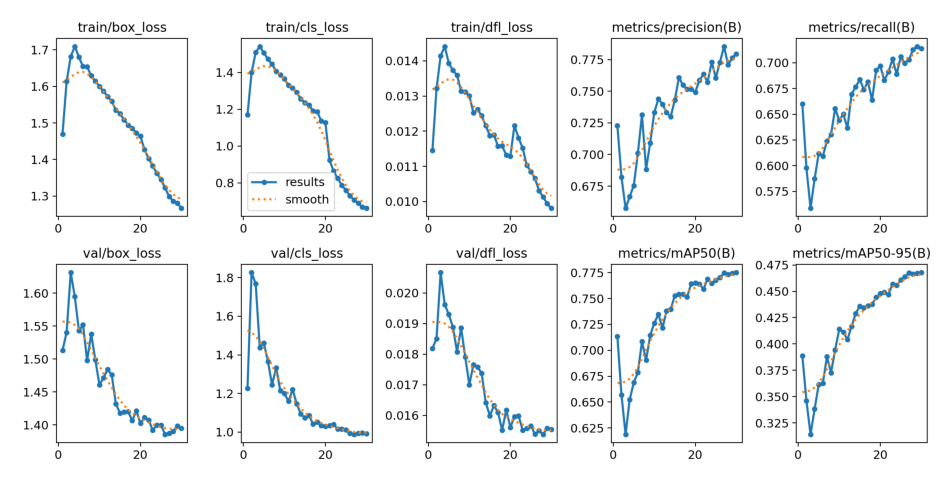

  Phase 1 → mAP50 = 0.785
  Phase 2 → mAP50 = 0.7751
  Gain    → -0.0099

Modèle : /kaggle/working/FireVision/finetune_final/weights/best.pt


In [8]:
# Courbes d'entraînement
img = mpimg.imread('/kaggle/working/FireVision/finetune_final/results.png')
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.show()

# Comparaison des scores
map50_phase2 = pd.read_csv('/kaggle/working/FireVision/finetune_final/results.csv')['metrics/mAP50(B)'].max()

print("=" * 40)
print(f"  Phase 1 → mAP50 = 0.785")
print(f"  Phase 2 → mAP50 = {map50_phase2:.4f}")
print(f"  Gain    → {map50_phase2 - 0.785:+.4f}")
print("=" * 40)
print("\nModèle : /kaggle/working/FireVision/finetune_final/weights/best.pt")